<a href="https://colab.research.google.com/github/Maria-Manzini/FUTURE_DS_03/blob/main/Task3_Marketing_Funnel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

print("Libraries ready ")

Libraries ready 


In [4]:
funnel_data = {
    'Stage': ['Visitors', 'Leads', 'Prospects', 'Qualified', 'Customers'],
    'Count': [10000, 4200, 1800, 720, 216]
}

channel_data = {
    'Channel': ['Social Media', 'Email', 'Paid Ads', 'Organic Search', 'Referral'],
    'Leads': [1200, 950, 800, 700, 550],
    'Conversions': [180, 190, 96, 140, 110],
}

monthly_data = {
    'Month': ['Jan','Feb','Mar','Apr','May','Jun'],
    'Leads': [620, 680, 750, 820, 900, 980],
    'Conversions': [31, 37, 45, 49, 58, 69]
}

df_funnel = pd.DataFrame(funnel_data)
df_channel = pd.DataFrame(channel_data)
df_monthly = pd.DataFrame(monthly_data)

df_channel['Conv_Rate'] = (df_channel['Conversions'] /
                            df_channel['Leads'] * 100).round(1)
df_monthly['Conv_Rate'] = (df_monthly['Conversions'] /
                            df_monthly['Leads'] * 100).round(1)

print("Datasets created ")
print("\nFunnel Stages:")
print(df_funnel)
print("\nChannel Performance:")
print(df_channel)

Datasets created 

Funnel Stages:
       Stage  Count
0   Visitors  10000
1      Leads   4200
2  Prospects   1800
3  Qualified    720
4  Customers    216

Channel Performance:
          Channel  Leads  Conversions  Conv_Rate
0    Social Media   1200          180       15.0
1           Email    950          190       20.0
2        Paid Ads    800           96       12.0
3  Organic Search    700          140       20.0
4        Referral    550          110       20.0


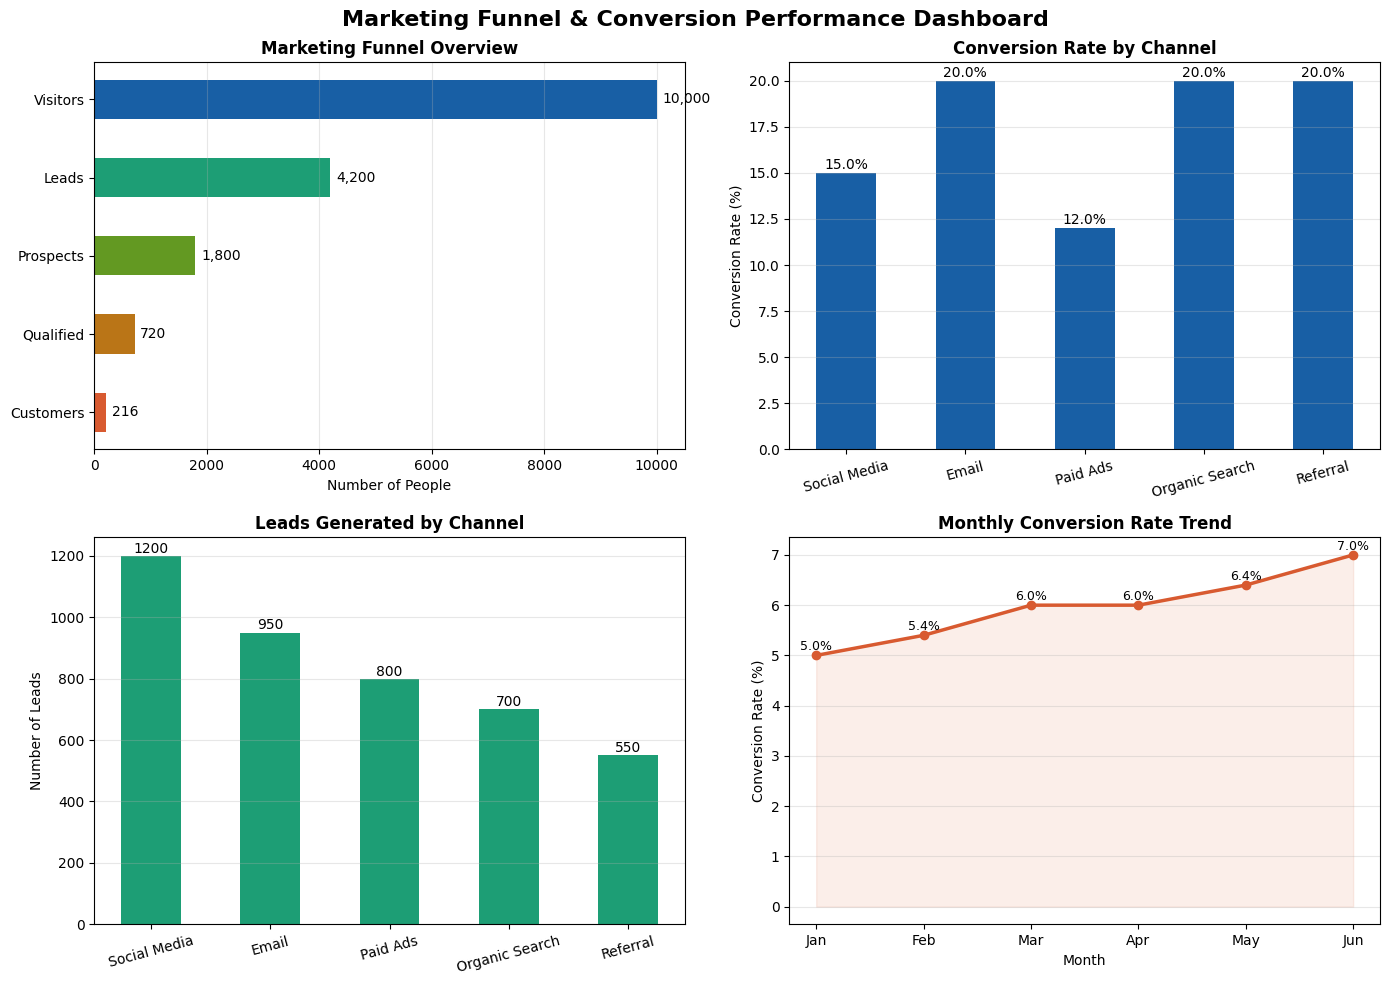

Chart saved as funnel_dashboard.png 


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Marketing Funnel & Conversion Performance Dashboard',
             fontsize=16, fontweight='bold')

# Chart 1: Funnel visualization (horizontal bar)
colors = ['#185FA5','#1D9E75','#639922','#BA7517','#D85A30']
bars = axes[0,0].barh(df_funnel['Stage'], df_funnel['Count'],
                       color=colors, height=0.5)
axes[0,0].set_title('Marketing Funnel Overview', fontweight='bold')
axes[0,0].set_xlabel('Number of People')
axes[0,0].invert_yaxis()
for bar, val in zip(bars, df_funnel['Count']):
    axes[0,0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                   f'{val:,}', va='center', fontsize=10)
axes[0,0].grid(axis='x', alpha=0.3)

# Chart 2: Conversion rate by channel (bar)
bars2 = axes[0,1].bar(df_channel['Channel'], df_channel['Conv_Rate'],
                       color='#185FA5', width=0.5)
axes[0,1].set_title('Conversion Rate by Channel', fontweight='bold')
axes[0,1].set_ylabel('Conversion Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, df_channel['Conv_Rate']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.2,
                   f'{val}%', ha='center', fontsize=10)
axes[0,1].grid(axis='y', alpha=0.3)

# Chart 3: Leads by channel (bar)
axes[1,0].bar(df_channel['Channel'], df_channel['Leads'],
              color='#1D9E75', width=0.5)
axes[1,0].set_title('Leads Generated by Channel', fontweight='bold')
axes[1,0].set_ylabel('Number of Leads')
axes[1,0].tick_params(axis='x', rotation=15)
for i, val in enumerate(df_channel['Leads']):
    axes[1,0].text(i, val + 10, str(val), ha='center', fontsize=10)
axes[1,0].grid(axis='y', alpha=0.3)

# Chart 4: Monthly conversion rate trend (line)
axes[1,1].plot(df_monthly['Month'], df_monthly['Conv_Rate'],
               color='#D85A30', linewidth=2.5, marker='o', markersize=6)
axes[1,1].fill_between(range(len(df_monthly)),
                        df_monthly['Conv_Rate'],
                        alpha=0.1, color='#D85A30')
axes[1,1].set_title('Monthly Conversion Rate Trend', fontweight='bold')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Conversion Rate (%)')
axes[1,1].grid(axis='y', alpha=0.3)
for i, val in enumerate(df_monthly['Conv_Rate']):
    axes[1,1].text(i, val + 0.1, f'{val}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('funnel_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as funnel_dashboard.png ")

In [6]:
print("=" * 48)
print("   MARKETING FUNNEL & CONVERSION INSIGHTS")
print("=" * 48)

overall_conv = (df_funnel['Count'].iloc[-1] /
                df_funnel['Count'].iloc[0] * 100)
print(f"\nOverall Funnel Conversion Rate: {overall_conv:.1f}%")
print(f"Visitors to Customers: {df_funnel['Count'].iloc[0]:,} → {df_funnel['Count'].iloc[-1]:,}")

print("\nBiggest Funnel Drop-offs:")
for i in range(len(df_funnel)-1):
    drop = ((df_funnel['Count'].iloc[i] - df_funnel['Count'].iloc[i+1]) /
             df_funnel['Count'].iloc[i] * 100)
    print(f"  {df_funnel['Stage'].iloc[i]} → {df_funnel['Stage'].iloc[i+1]}: {drop:.1f}% drop")

best_channel = df_channel.loc[df_channel['Conv_Rate'].idxmax()]
print(f"\nBest Converting Channel: {best_channel['Channel']} ({best_channel['Conv_Rate']}%)")

most_leads = df_channel.loc[df_channel['Leads'].idxmax()]
print(f"Most Leads Generated: {most_leads['Channel']} ({most_leads['Leads']} leads)")

print(f"\nConversion Rate Growth Jan-Jun: {df_monthly['Conv_Rate'].iloc[0]}% → {df_monthly['Conv_Rate'].iloc[-1]}%")

print("\nRECOMMENDATIONS:")
print("1. Reduce Visitor → Lead drop-off with better")
print("   landing pages and clear calls-to-action")
print("2. Invest more budget in Email marketing —")
print("   highest conversion rate channel")
print("3. Nurture Prospects better to improve the")
print("   Prospect → Qualified conversion rate")
print("4. Replicate what's working in Jun to sustain")
print("   the upward conversion trend")
print("=" * 48)

   MARKETING FUNNEL & CONVERSION INSIGHTS

Overall Funnel Conversion Rate: 2.2%
Visitors to Customers: 10,000 → 216

Biggest Funnel Drop-offs:
  Visitors → Leads: 58.0% drop
  Leads → Prospects: 57.1% drop
  Prospects → Qualified: 60.0% drop
  Qualified → Customers: 70.0% drop

Best Converting Channel: Email (20.0%)
Most Leads Generated: Social Media (1200 leads)

Conversion Rate Growth Jan-Jun: 5.0% → 7.0%

RECOMMENDATIONS:
1. Reduce Visitor → Lead drop-off with better
   landing pages and clear calls-to-action
2. Invest more budget in Email marketing —
   highest conversion rate channel
3. Nurture Prospects better to improve the
   Prospect → Qualified conversion rate
4. Replicate what's working in Jun to sustain
   the upward conversion trend
